# Credit Card Fraud Detection: Unsupervised Learning Analysis

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **Credit Card Fraud Detection** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on practical implementation details, including data preparation, model development, training procedures, evaluation workflows, and complementary computational experiments.

## Imports and Configuration

This section imports the libraries required throughout the analysis and defines the configuration settings used to ensure reproducibility of the experiments.

In [1]:
# Standard libraries
import os
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Unsupervised learning models
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

# Dimensionality reduction
from sklearn.decomposition import PCA

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Reproducibility configuration
random_state = 42

np.random.seed(random_state)

# Suppress warning messages
warnings.filterwarnings("ignore")

# Visualization configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading

This section loads the credit card transaction dataset and performs an initial inspection of its structure. The objective is to verify the number of observations, the available variables, and the distribution of the target variable before moving into exploratory analysis and preprocessing.

In [2]:
# Define data path
data_path = "../data/creditcard.csv"

# Load dataset
df = pd.read_csv(data_path)

# Display basic structure
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

df.head()

Number of rows: 284,807
Number of columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Inspect column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# Inspect target distribution
class_distribution = df["Class"].value_counts().sort_index()
class_distribution_percentage = df["Class"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": class_distribution,
    "percentage": class_distribution_percentage
})

target_summary

,count,percentage
Class,,
0,284315,99.827251
1,492,0.172749


## Exploratory Data Analysis

This section explores the main characteristics of the dataset. Particular attention is given to the class imbalance, transaction amounts, and the distribution of the anonymized features used throughout the analysis.

### Class Distribution

Credit card fraud datasets are typically characterized by a severe class imbalance. Understanding the magnitude of this imbalance is important because it influences both model training and evaluation.

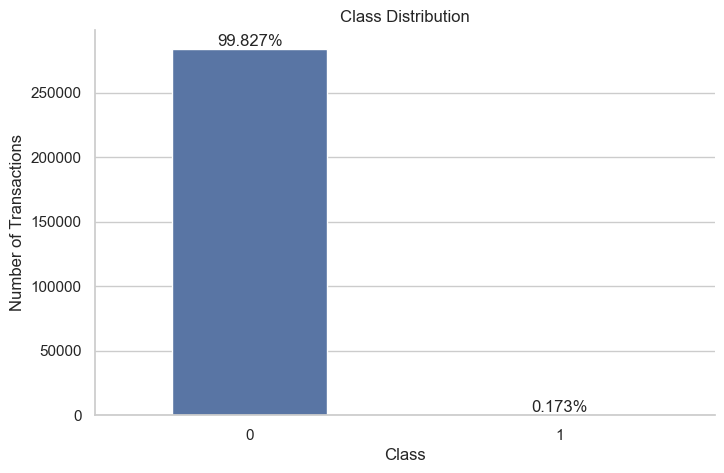

In [5]:
# Plot class distribution
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

# Bar width
for bar in ax.patches:
    current_width = bar.get_width()
    new_width = 0.5
    diff = current_width - new_width
    bar.set_width(new_width)
    bar.set_x(
        bar.get_x() + diff / 2
    )

total_transactions = class_counts.sum()

for i, value in enumerate(class_counts.values):
    percentage = (
        value / total_transactions
    ) * 100
    ax.text(
        i,
        value,
        f"{percentage:.3f}%",
        ha="center",
        va="bottom"
    )

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")

sns.despine()

plt.show()

In [6]:
# Fraud rate
fraud_rate = df["Class"].mean() * 100

print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1727%


### Transaction Amount Analysis

The transaction amount is one of the few variables presented in its original scale. Examining its distribution provides additional context regarding the range and concentration of transaction values.

In [7]:
# Summary statistics
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

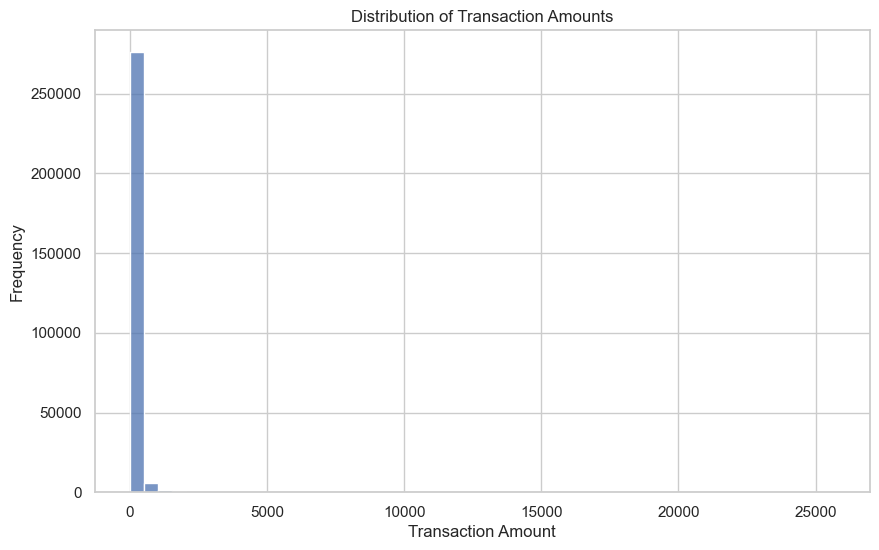

In [8]:
# Transaction amount distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Amount"],
    bins=50
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")
plt.show()

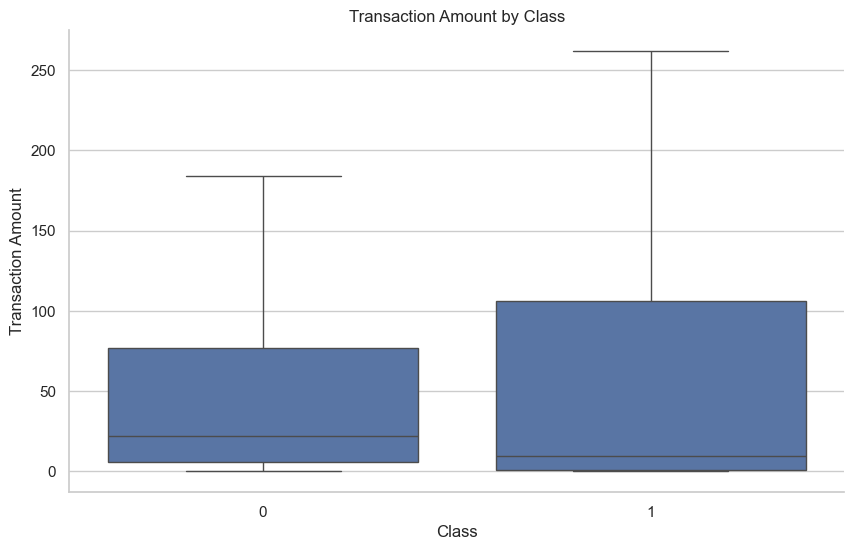

In [9]:
# Transaction amount by class
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount by Class")

sns.despine()
plt.show()

### Feature Distributions

The variables V1–V28 correspond to principal components obtained through a prior anonymization process. Selected variables are visualized to compare the distributions of fraudulent and legitimate transactions.

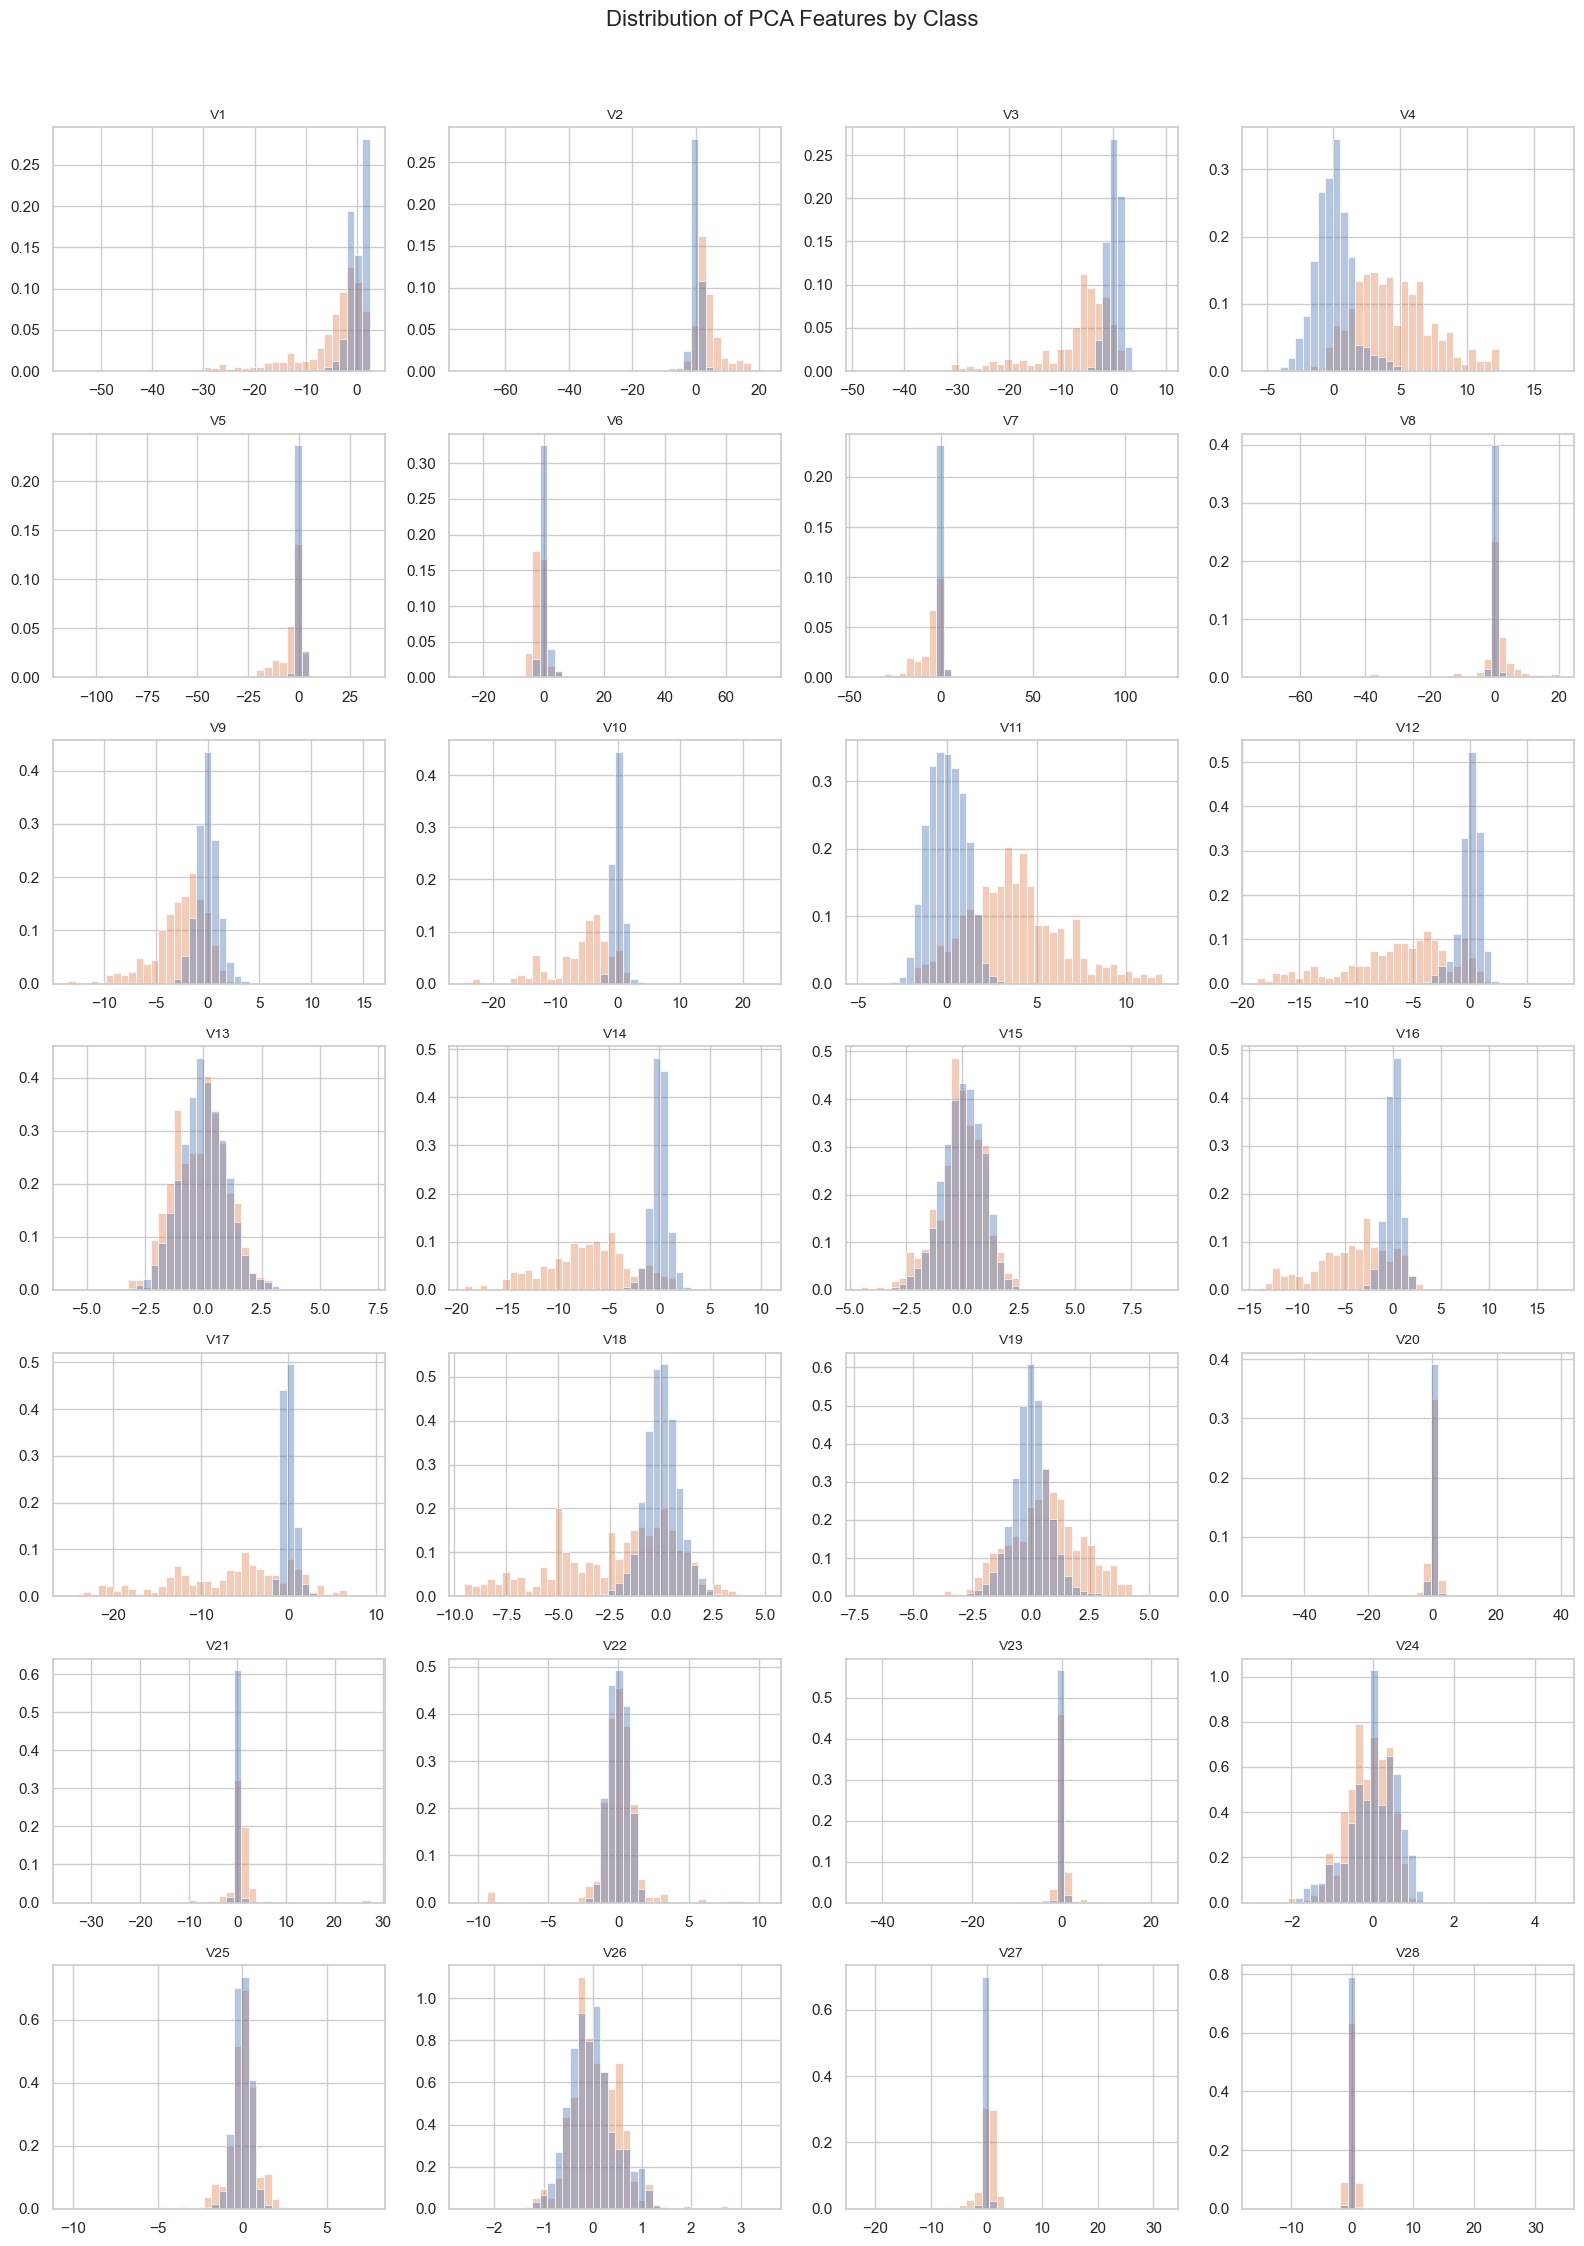

In [10]:
# Distribution of PCA features by class
pca_features = [
    f"V{i}"
    for i in range(1, 29)
]

fig, axes = plt.subplots(
    nrows=7,
    ncols=4,
    figsize=(16, 22)
)

axes = axes.flatten()

for i, feature in enumerate(pca_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        stat="density",
        common_norm=False,
        bins=40,
        alpha=0.4,
        edgecolor=None,
        ax=axes[i]
    )

    axes[i].set_title(
        feature,
        fontsize=10
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    legend = axes[i].get_legend()

    if legend is not None:
        legend.remove()

for ax in axes[len(pca_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distribution of PCA Features by Class",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Correlation Structure

A correlation matrix is used to identify linear relationships among the available variables and to assess whether fraudulent behavior exhibits associations with specific features.

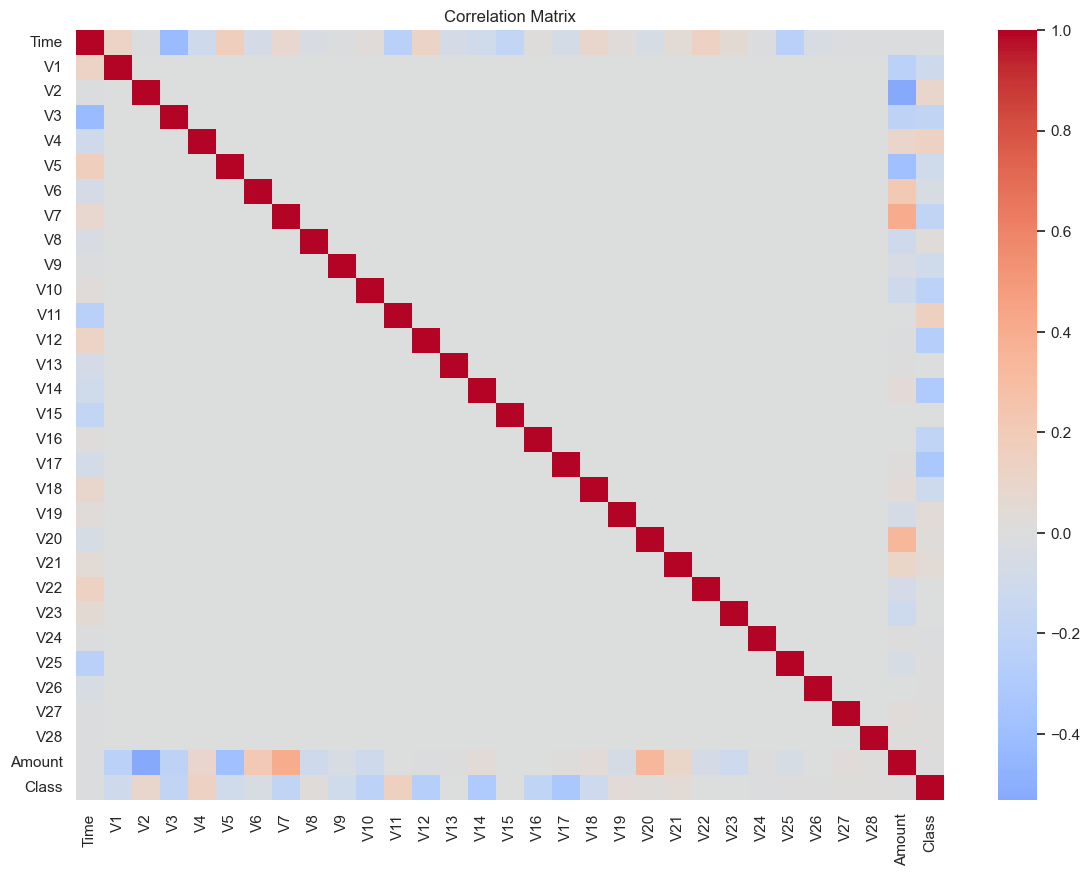

In [11]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Data Preparation

This section prepares the dataset for unsupervised and supervised learning. The target variable is separated from the feature matrix, the `Time` variable is removed, and the data is split into training and test sets using stratification to preserve the original class imbalance.

Feature scaling is applied after the train-test split to avoid data leakage. The scaler is fitted only on the training data and then applied to both the training and test sets.

In [12]:
# Separate feature matrix and target variable
X = df.drop(columns=["Class"])
y = df["Class"]

# Remove Time variable
X = X.drop(columns=["Time"])

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=random_state
)

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Inspect prepared data
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Training fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Test fraud rate: {y_test.mean() * 100:.4f}%")

Training set shape: (227845, 29)
Test set shape: (56962, 29)
Training fraud rate: 0.1729%
Test fraud rate: 0.1720%


## Unsupervised Learning Analysis

This section examines whether fraudulent transactions exhibit detectable structure in the feature space. Clustering methods are applied to the scaled training data, and the resulting groups are evaluated by comparing their fraud concentration against the baseline fraud rate.

Because the training set contains more than two hundred thousand observations, some clustering algorithms become computationally expensive when applied to the full dataset. To ensure a consistent comparison across methods, all clustering algorithms are applied to the same stratified sample extracted from the training set. This preserves the original class distribution while keeping the analysis computationally tractable.

### Stratified Sample for Clustering

A stratified sample is created from the scaled training set. The sample preserves the proportion of fraudulent and legitimate transactions observed in the training data and is used consistently across K-Means, Agglomerative Clustering, and DBSCAN.

In [13]:
# Define sample size for clustering analysis
sample_size = 20000

# Combine scaled features and target variable
train_sample = X_train_scaled.copy()
train_sample["Class"] = y_train.values

# Compute sampling fraction
sample_fraction = sample_size / len(train_sample)

# Create stratified sample
train_sample = (
    train_sample
    .groupby("Class", group_keys=False)
    .sample(
        frac=sample_fraction,
        random_state=random_state
    )
)

# Separate features and target variable
X_train_sample_scaled = train_sample.drop(columns=["Class"])
y_train_sample = train_sample["Class"]

# Inspect sample structure
print(f"Sample shape: {X_train_sample_scaled.shape}")
print(f"Training fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Sample fraud rate: {y_train_sample.mean() * 100:.4f}%")

Sample shape: (20000, 29)
Training fraud rate: 0.1729%
Sample fraud rate: 0.1750%


In [14]:
# Define baseline fraud rate for cluster evaluation
baseline_fraud_rate = y_train_sample.mean() * 100

print(f"Baseline fraud rate in clustering sample: {baseline_fraud_rate:.4f}%")

Baseline fraud rate in clustering sample: 0.1750%


### K-Means Clustering

K-Means partitions observations into a predefined number of clusters by minimizing the within-cluster sum of squares. The resulting clusters are examined to determine whether fraudulent transactions are concentrated in specific regions of the feature space.

Because the elbow plot does not provide a clear inflection point, additional internal validation metrics are computed for different values of `k`. The Silhouette score, Calinski-Harabasz index, and Davies-Bouldin index are used together with inertia to support the final choice of the number of clusters.

In [15]:
# Import clustering validation metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

In [16]:
# Evaluate K-Means for different numbers of clusters
k_values = range(2, 16)

kmeans_results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_train_sample_scaled
    )

    kmeans_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(
            X_train_sample_scaled,
            labels
        ),
        "calinski_harabasz_score": calinski_harabasz_score(
            X_train_sample_scaled,
            labels
        ),
        "davies_bouldin_score": davies_bouldin_score(
            X_train_sample_scaled,
            labels
        )
    })

kmeans_metrics = pd.DataFrame(kmeans_results)

kmeans_metrics

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,558593.833185,0.439875,748.042116,1.895096
1,3,538542.033890,0.167635,760.206815,2.228170
2,4,521438.470671,0.065249,742.029736,3.062688
3,5,504843.841589,0.068854,739.099890,3.036557
4,6,491179.483520,0.072778,718.943156,2.776179
5,7,473342.793618,0.063807,747.228942,2.536814
6,8,463876.855604,0.080155,711.799531,2.589272
7,9,449518.297333,0.074764,722.506086,2.409014
8,10,439906.115073,0.065015,704.759598,2.362571
9,11,424544.174636,0.067903,729.532844,2.268957


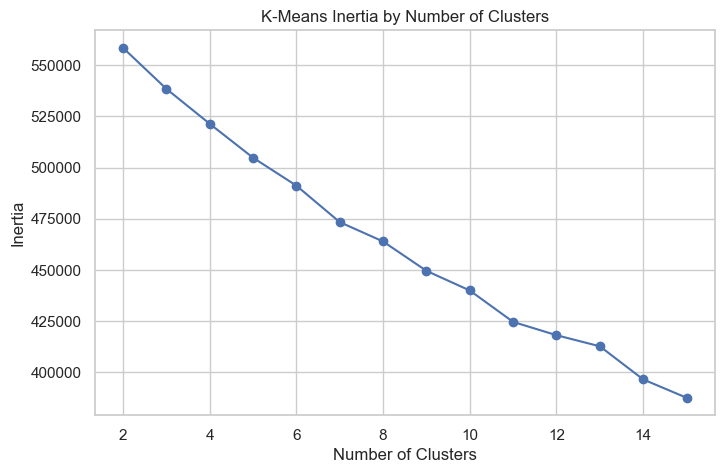

In [17]:
# Plot inertia values
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_metrics["k"],
    kmeans_metrics["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("K-Means Inertia by Number of Clusters")

plt.show()

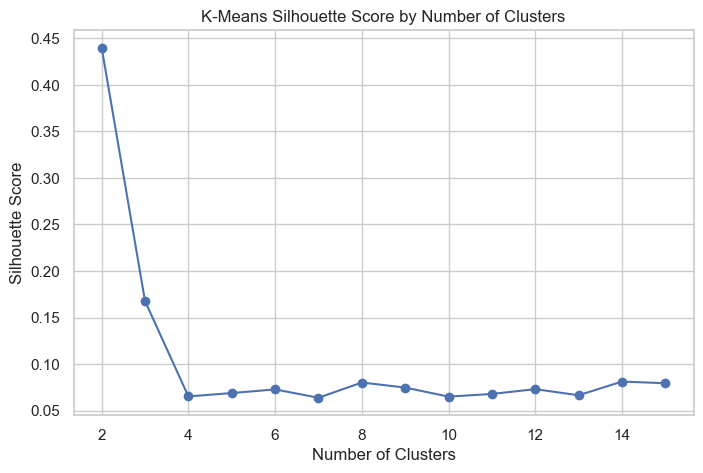

In [18]:
# Plot Silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_metrics["k"],
    kmeans_metrics["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score by Number of Clusters")

plt.show()

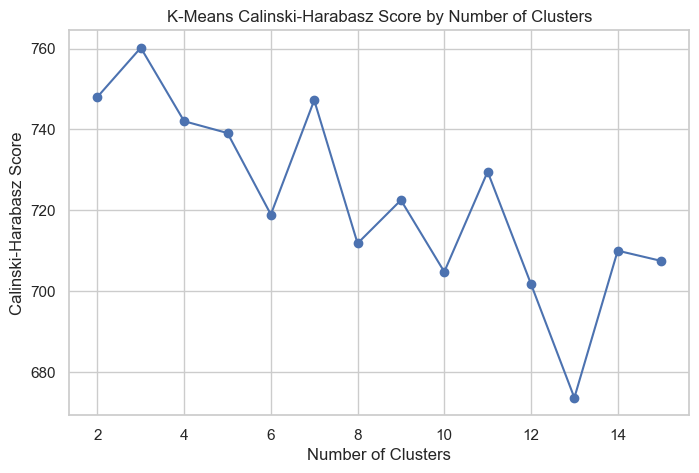

In [19]:
# Plot Calinski-Harabasz scores
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_metrics["k"],
    kmeans_metrics["calinski_harabasz_score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.title("K-Means Calinski-Harabasz Score by Number of Clusters")

plt.show()

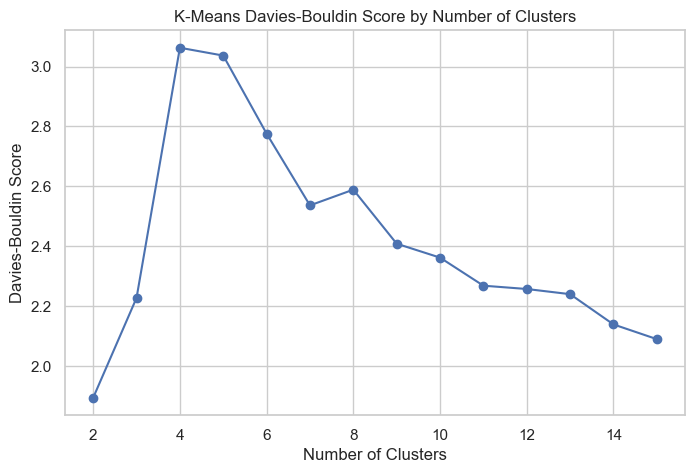

In [20]:
# Plot Davies-Bouldin scores
plt.figure(figsize=(8, 5))

plt.plot(
    kmeans_metrics["k"],
    kmeans_metrics["davies_bouldin_score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.title("K-Means Davies-Bouldin Score by Number of Clusters")

plt.show()

The validation metrics are used as diagnostic tools rather than as a mechanical rule for selecting the number of clusters. Since the purpose of this stage is exploratory, the selected value of `k` should balance metric performance and interpretability.

Although internal validation metrics were evaluated for multiple values of k, no single criterion provided a definitive choice. The elbow method did not reveal a clear inflection point, while different validation metrics favored different cluster configurations.

From an exploratory perspective, the three-cluster solution revealed the strongest concentration of fraudulent transactions. One cluster exhibited a fraud rate approximately twenty-one times higher than the baseline fraud rate, suggesting the presence of a distinct region of the feature space associated with fraudulent behavior. For this reason, a three-cluster solution was retained for the remainder of the analysis.

In [21]:
# Set number of clusters for K-Means
n_clusters = 3

In [22]:
# Fit final K-Means model
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=random_state,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_train_sample_scaled
)

In [23]:
# Compute final K-Means validation metrics
kmeans_silhouette = silhouette_score(
    X_train_sample_scaled,
    kmeans_labels
)

kmeans_calinski_harabasz = calinski_harabasz_score(
    X_train_sample_scaled,
    kmeans_labels
)

kmeans_davies_bouldin = davies_bouldin_score(
    X_train_sample_scaled,
    kmeans_labels
)

print(f"Silhouette score: {kmeans_silhouette:.4f}")
print(f"Calinski-Harabasz score: {kmeans_calinski_harabasz:.4f}")
print(f"Davies-Bouldin score: {kmeans_davies_bouldin:.4f}")

Silhouette score: 0.1676
Calinski-Harabasz score: 760.2068
Davies-Bouldin score: 2.2282


### K-Means Cluster Composition

The composition of each cluster is examined by comparing its fraud rate against the baseline fraud rate in the clustering sample. The fraud lift indicates how many times higher or lower the fraud concentration of a cluster is relative to the sample baseline.

In [24]:
# Analyze fraud concentration by K-Means cluster
kmeans_cluster_summary = pd.DataFrame({
    "cluster": kmeans_labels,
    "Class": y_train_sample.values
})

kmeans_cluster_summary = (
    kmeans_cluster_summary
    .groupby("cluster")
    .agg(
        transactions=("Class", "size"),
        fraud_count=("Class", "sum"),
        fraud_rate=("Class", "mean")
    )
)

kmeans_cluster_summary["fraud_rate"] *= 100

kmeans_cluster_summary["fraud_lift"] = (
    kmeans_cluster_summary["fraud_rate"]
    / baseline_fraud_rate
)

kmeans_cluster_summary = (
    kmeans_cluster_summary
    .sort_values(
        "fraud_lift",
        ascending=False
    )
)

kmeans_cluster_summary

,transactions,fraud_count,fraud_rate,fraud_lift
cluster,,,,
2,464,17,3.663793,20.935961
0,1427,3,0.210231,1.201321
1,18109,15,0.082832,0.473324


In [25]:
print(
    f"Baseline fraud rate: "
    f"{baseline_fraud_rate:.4f}%"
)

Baseline fraud rate: 0.1750%


The results indicate that the clusters are not equally associated with fraudulent activity. In particular, one cluster exhibits a substantially higher fraud rate than the baseline rate observed in the sample. This suggests that fraudulent transactions may occupy specific regions of the feature space rather than being uniformly distributed across all observations.

### Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method that builds nested groups through successive merges. Unlike K-Means, which partitions observations around centroids, Agglomerative Clustering constructs clusters based on pairwise similarity relationships among observations.

To facilitate comparison with K-Means, the number of clusters is fixed at three.

In [26]:
# Fit Agglomerative Clustering model
agglomerative = AgglomerativeClustering(
    n_clusters=n_clusters
)

agglomerative_labels = agglomerative.fit_predict(
    X_train_sample_scaled
)

In [27]:
# Compute clustering validation metrics
agglomerative_silhouette = silhouette_score(
    X_train_sample_scaled,
    agglomerative_labels
)

agglomerative_calinski_harabasz = (
    calinski_harabasz_score(
        X_train_sample_scaled,
        agglomerative_labels
    )
)

agglomerative_davies_bouldin = (
    davies_bouldin_score(
        X_train_sample_scaled,
        agglomerative_labels
    )
)

print(
    f"Silhouette score: "
    f"{agglomerative_silhouette:.4f}"
)

print(
    f"Calinski-Harabasz score: "
    f"{agglomerative_calinski_harabasz:.4f}"
)

print(
    f"Davies-Bouldin score: "
    f"{agglomerative_davies_bouldin:.4f}"
)

Silhouette score: 0.3366
Calinski-Harabasz score: 686.4297
Davies-Bouldin score: 1.6934


### Agglomerative Cluster Composition

The composition of each cluster is examined by comparing its fraud rate against the baseline fraud rate in the clustering sample. The fraud lift indicates how many times higher or lower the fraud concentration of a cluster is relative to the sample baseline.

In [28]:
# Analyze fraud concentration by Agglomerative cluster
agglomerative_cluster_summary = pd.DataFrame({
    "cluster": agglomerative_labels,
    "Class": y_train_sample.values
})

agglomerative_cluster_summary = (
    agglomerative_cluster_summary
    .groupby("cluster")
    .agg(
        transactions=("Class", "size"),
        fraud_count=("Class", "sum"),
        fraud_rate=("Class", "mean")
    )
)

agglomerative_cluster_summary["fraud_rate"] *= 100

agglomerative_cluster_summary["fraud_lift"] = (
    agglomerative_cluster_summary["fraud_rate"]
    / baseline_fraud_rate
)

agglomerative_cluster_summary = (
    agglomerative_cluster_summary
    .sort_values(
        "fraud_lift",
        ascending=False
    )
)

agglomerative_cluster_summary

,transactions,fraud_count,fraud_rate,fraud_lift
cluster,,,,
1,14,12,85.714286,489.795918
2,666,1,0.150150,0.858001
0,19320,22,0.113872,0.650695


In [29]:
print(
    f"Baseline fraud rate: "
    f"{baseline_fraud_rate:.4f}%"
)

Baseline fraud rate: 0.1750%


The distribution of fraud across the hierarchical clusters provides an alternative perspective on the structure of the transaction space. Comparing the fraud concentration observed in these clusters with the results obtained from K-Means helps assess whether the detected patterns are robust across different clustering methodologies.

### DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups observations according to local density rather than predefined cluster assignments. Unlike K-Means and Agglomerative Clustering, DBSCAN can identify observations that do not belong to any cluster and label them as noise.

This characteristic makes DBSCAN particularly relevant for fraud detection, where fraudulent transactions may appear as isolated or unusual observations rather than as members of large homogeneous groups.

### Selection of DBSCAN Parameters

DBSCAN requires two parameters:

- `eps`, which defines the neighborhood radius around each observation.
- `min_samples`, which specifies the minimum number of neighboring observations required to form a dense region.

Because no universally optimal values exist, several parameter combinations are explored before fitting the final model.

In [30]:
# Evaluate different DBSCAN configurations
dbscan_results = []

eps_values = [1.0, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 20]

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            X_train_sample_scaled
        )

        n_clusters = len(
            set(labels)
        ) - (
            1 if -1 in labels else 0
        )

        n_noise = np.sum(
            labels == -1
        )

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_points": n_noise
        })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results

,eps,min_samples,n_clusters,noise_points
0,1.0,5,244,16041
1,1.0,10,62,17778
2,1.0,20,21,18736
3,1.5,5,192,12099
4,1.5,10,94,13853
5,1.5,20,43,16028
6,2.0,5,154,8204
7,2.0,10,68,9990
8,2.0,20,31,11837
9,2.5,5,47,4948


The results indicate that DBSCAN is highly sensitive to the choice of `eps` and `min_samples`. Smaller neighborhood radii produce a large number of clusters and classify a substantial proportion of observations as noise, while larger values yield a more compact clustering structure.

For the purposes of this exploratory analysis, a configuration of `eps = 2.5` and `min_samples = 20` is retained. This specification produces a manageable number of clusters while preserving DBSCAN's ability to identify observations that do not belong to any dense region of the feature space.

In [31]:
# Set DBSCAN parameters
eps = 2.5
min_samples = 20

In [32]:
# Fit DBSCAN model
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

dbscan_labels = dbscan.fit_predict(
    X_train_sample_scaled
)

In [33]:
# Number of clusters and noise points
n_clusters = len(
    set(dbscan_labels)
) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(
    dbscan_labels == -1
)

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Number of clusters: 12
Noise points: 7065


### DBSCAN Cluster Composition

The composition of each cluster is examined by comparing its fraud rate against the baseline fraud rate in the clustering sample. Particular attention is given to observations classified as noise, since these transactions do not belong to any dense region identified by the algorithm.

In [34]:
# Analyze fraud concentration by DBSCAN cluster
dbscan_cluster_summary = pd.DataFrame({
    "cluster": dbscan_labels,
    "Class": y_train_sample.values
})

dbscan_cluster_summary = (
    dbscan_cluster_summary
    .groupby("cluster")
    .agg(
        transactions=("Class", "size"),
        fraud_count=("Class", "sum"),
        fraud_rate=("Class", "mean")
    )
)

dbscan_cluster_summary["fraud_rate"] *= 100

dbscan_cluster_summary["fraud_lift"] = (
    dbscan_cluster_summary["fraud_rate"]
    / baseline_fraud_rate
)

dbscan_cluster_summary = (
    dbscan_cluster_summary
    .sort_values(
        "fraud_lift",
        ascending=False
    )
)

dbscan_cluster_summary

,transactions,fraud_count,fraud_rate,fraud_lift
cluster,,,,
-1,7065,35,0.4954,2.830856
0,9024,0,0.0000,0.000000
1,157,0,0.0000,0.000000
2,443,0,0.0000,0.000000
3,847,0,0.0000,0.000000
4,1074,0,0.0000,0.000000
5,524,0,0.0000,0.000000
6,554,0,0.0000,0.000000
7,155,0,0.0000,0.000000


In [35]:
print(
    f"Baseline fraud rate: "
    f"{baseline_fraud_rate:.4f}%"
)

Baseline fraud rate: 0.1750%


In [36]:
# Fraud concentration among noise points
noise_points = pd.DataFrame({
    "cluster": dbscan_labels,
    "Class": y_train_sample.values
})

noise_points = noise_points[
    noise_points["cluster"] == -1
]

noise_fraud_rate = (
    noise_points["Class"].mean() * 100
)

noise_fraud_lift = (
    noise_fraud_rate
    / baseline_fraud_rate
)

print(
    f"Noise fraud rate: "
    f"{noise_fraud_rate:.4f}%"
)

print(
    f"Noise fraud lift: "
    f"{noise_fraud_lift:.4f}"
)

Noise fraud rate: 0.4954%
Noise fraud lift: 2.8309


The distribution of fraud across density-based clusters provides a complementary perspective to the results obtained from K-Means and Agglomerative Clustering. In particular, the concentration of fraudulent transactions among observations classified as noise may indicate that certain fraud patterns behave as isolated anomalies rather than members of well-defined clusters.

### Comparison of Clustering Results

The three clustering algorithms provide complementary perspectives on the structure of fraudulent transactions. Rather than producing identical results, each method highlights a different aspect of the transaction space.

K-Means identifies a relatively large region characterized by an elevated concentration of fraudulent transactions. Agglomerative Clustering isolates a much smaller group exhibiting an exceptionally high fraud rate. In contrast, DBSCAN classifies all fraudulent transactions as noise, suggesting that fraudulent behavior may appear as atypical observations rather than members of dense regions.

Taken together, these results provide evidence that fraudulent transactions are not uniformly distributed across the feature space. Although the exact structure depends on the clustering methodology, all three approaches indicate that fraud occupies distinct regions that differ from the bulk of legitimate transactions.

In [37]:
# Summary of clustering results
clustering_summary = pd.DataFrame({
    "method": [
        "K-Means",
        "Agglomerative Clustering",
        "DBSCAN"
    ],
    "key_finding": [
        "Fraud lift ≈ 21 in one cluster",
        "Fraud lift ≈ 490 in a micro-cluster",
        "All frauds classified as noise"
    ]
})

clustering_summary

,method,key_finding
0,K-Means,Fraud lift ≈ 21 in one cluster
1,Agglomerative Clustering,Fraud lift ≈ 490 in a micro-cluster
2,DBSCAN,All frauds classified as noise


### Summary

The clustering analysis provides preliminary evidence that fraudulent transactions exhibit detectable structure within the available feature space. While the specific patterns vary across algorithms, all methods identify behavior that differs substantially from the baseline distribution of legitimate transactions.

These findings support the central hypothesis of the project and motivate the supervised learning stage. If fraudulent transactions leave identifiable signatures in the feature space, predictive models should be able to exploit this structure to distinguish fraudulent and legitimate transactions more effectively.